In [1]:
# 6. 통신사 해지 고객 예측

In [216]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [217]:
from matplotlib import font_manager, rc
import platform

system = platform.system()

if system == 'Windows':
    rc('font', family='Malgun Gothic')

elif system == 'Darwin':  # macOS
    rc('font', family='AppleGothic')

else:  # Linux 등
    rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

In [218]:
## 02. 데이터 불러오기

In [219]:
telecom_df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/telecom.csv')
telecom_df.head()

,고객ID,연령,성별,지역,가입기간,월요금,총요금,상담횟수,데이터사용량,계약유형,해지여부
0,C00001,32.0,여성,서울,24,65500,1572000.0,1,15.2,1년약정,0
1,C00002,55.0,남성,경기,2,89000,178000.0,5,5.0,약정없음,1
2,C00003,28.0,여성,부산,48,45200,2169600.0,0,22.1,2년약정,0
3,C00004,41.0,남성,서울,1,105300,105300.0,4,8.5,약정없음,1
4,C00005,62.0,여성,기타,12,75000,NaN,2,10.2,약정없음,0


In [220]:
## 03. 데이터 시각화 해석

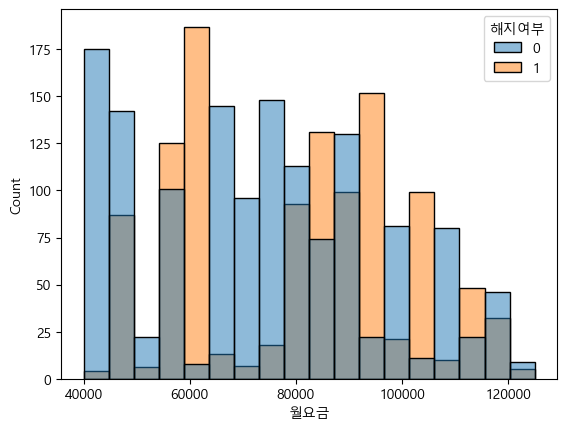

In [221]:
sns.histplot(
    data = telecom_df,
    x = '월요금',
    hue = '해지여부'
)
plt.show()

In [222]:
정답_3 = 1

In [223]:
## 04. 결측치 처리 1

In [224]:
telecom_df['연령'] = telecom_df['연령'].fillna(telecom_df['연령'].mean())
telecom_df['지역'] = telecom_df['지역'].fillna(telecom_df['지역'].mode()[0])

In [225]:
문제4_1 = 'mean()'
문제4_2 = 'mode()[0]'

In [226]:
## 05. 결측치 처리 2 

In [227]:
telecom_df['총요금'] = telecom_df['총요금'].fillna(telecom_df['월요금'] * telecom_df['가입기간'])

In [228]:
telecom_df.drop_duplicates(subset = '고객ID', inplace = True)

In [229]:
## 06. 데이터 정제

In [230]:
telecom_df.drop(columns = '고객ID', inplace = True)

In [231]:
telecom_df.drop(telecom_df[(telecom_df['상담횟수'] == 0) & (telecom_df['월요금'] >= 110000)].index, inplace = True)

In [232]:
((telecom_df['월요금'] >= 110000) & (telecom_df['상담횟수'] == 0)).sum()

np.int64(0)

In [233]:
## 07. 범주형 변수 인코딩

In [234]:
telecom_df['성별'] = telecom_df['성별'].map({'여성' : 0, '남성' : 1})

In [235]:
telecom_df = pd.get_dummies(data = telecom_df, columns = ['지역', '계약유형'])

In [236]:
telecom_df

,연령,성별,가입기간,월요금,총요금,상담횟수,데이터사용량,해지여부,지역_경기,지역_기타,지역_대구,지역_부산,지역_서울,계약유형_1년약정,계약유형_2년약정,계약유형_약정없음
0,32.0,0,24,65500,1572000.0,1,15.2,0,False,False,False,False,True,True,False,False
1,55.0,1,2,89000,178000.0,5,5.0,1,True,False,False,False,False,False,False,True
2,28.0,0,48,45200,2169600.0,0,22.1,0,False,False,False,True,False,False,True,False
3,41.0,1,1,105300,105300.0,4,8.5,1,False,False,False,False,True,False,False,True
4,62.0,0,12,75000,900000.0,2,10.2,0,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2557,38.0,0,48,88500,4248000.0,0,33.1,0,False,True,False,False,False,False,True,False
2558,21.0,1,8,62000,496000.0,3,14.5,1,False,False,False,False,True,False,False,True
2559,47.0,0,30,72300,2169000.0,1,28.7,0,True,False,False,False,False,True,False,False
2560,53.0,1,14,85000,1190000.0,4,19.2,1,False,False,False,True,False,False,False,True


In [237]:
## 08. 데이터 분리 및 분할
from sklearn.model_selection import train_test_split

In [238]:
X = telecom_df.drop(columns = '해지여부')

In [239]:
y = telecom_df['해지여부']

In [240]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [241]:
## 09.  수치형 데이터 스케일링

In [242]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = X_train[['연령', '가입기간', '월요금', '총요금']]
X_test_num = X_test[['연령', '가입기간', '월요금', '총요금']]

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [243]:
X_train

,연령,성별,가입기간,월요금,총요금,상담횟수,데이터사용량,지역_경기,지역_기타,지역_대구,지역_부산,지역_서울,계약유형_1년약정,계약유형_2년약정,계약유형_약정없음
2433,58.000000,0,5,92500,462500.0,4,6.7,False,False,False,False,True,False,False,True
936,60.000000,1,60,112000,6720000.0,1,58.9,True,False,False,False,False,False,True,False
1524,28.000000,0,48,45200,2169600.0,0,22.1,False,False,False,True,False,False,True,False
2504,59.000000,1,66,120000,7920000.0,1,60.1,True,False,False,False,False,False,True,False
1505,29.000000,1,24,55000,1320000.0,2,25.4,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,33.000000,0,10,78200,782000.0,3,11.0,False,False,False,False,True,False,False,True
2163,33.000000,0,12,79500,954000.0,2,16.4,False,False,False,False,True,False,False,True
2402,33.000000,1,10,78200,782000.0,3,11.0,False,True,False,False,False,False,False,True
2391,40.000000,0,2,86000,172000.0,5,3.8,False,False,True,False,False,False,False,True


In [244]:
X_train_class = X_train[['연령', '가입기간', '월요금', '총요금', '데이터사용량', '상담횟수']]

In [245]:
X_test_class = X_test[['연령', '가입기간', '월요금', '총요금', '데이터사용량', '상담횟수']]

In [246]:
X_train_scaled = scaler.fit_transform(X_train_class)
X_test_scaled = scaler.transform(X_test_class)

In [247]:
## 10. 머신러닝 모델 구축

In [248]:
from sklearn.ensemble import RandomForestClassifier

In [249]:
from sklearn.linear_model import LogisticRegression

In [250]:
lr_model = LogisticRegression(random_state = 42, max_iter = 1000, C = 0.1)

In [251]:
rf_model = RandomForestClassifier(random_state = 42, max_depth = 5, min_samples_split = 5, n_estimators = 50)

In [252]:
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [253]:
rf_model.fit(X_train_scaled, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [254]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(10)

In [255]:
## 11. 머신러닝 모델 성능 비교

In [256]:
model_lr_pred = lr_model.predict(X_test_scaled)

In [257]:
model_rf_pred = rf_model.predict(X_test_scaled)

In [258]:
from sklearn.metrics import accuracy_score, f1_score

In [259]:
acc_lr = accuracy_score(y_test, model_lr_pred)
acc_lr

0.998

In [260]:
acc_rf = accuracy_score(y_test, model_rf_pred)

In [261]:
f1_lr = f1_score(y_test, model_lr_pred)

In [262]:
f1_rf = f1_score(y_test, model_rf_pred)

In [263]:
f1_rf

1.0

In [264]:
import pandas as pd
df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/telecom.csv')
# 가입기간별 해지율
print(df.groupby('가입기간')['해지여부'].mean())
# 계약유형별 해지율
print(df.groupby('계약유형')['해지여부'].mean())

가입기간
1     1.000000
2     1.000000
3     1.000000
4     1.000000
5     0.576471
6     0.909091
8     1.000000
10    0.638889
12    0.054545
14    0.888889
15    0.008772
18    0.126984
20    0.000000
24    0.000000
30    0.000000
36    0.000000
40    0.000000
42    0.000000
48    0.000000
50    0.000000
55    0.000000
60    0.000000
66    0.000000
70    0.000000
72    0.000000
Name: 해지여부, dtype: float64
계약유형
1년약정    0.000000
2년약정    0.000000
약정없음    0.820346
Name: 해지여부, dtype: float64
